In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

In [2]:
import os
import sys
import glob
import itertools as it
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
plt.rcParams['font.family'] = 'serif'
import seaborn as sns

import gwpy.table
import cogwheel.cosmology
from cogwheel import utils
from cogwheel.likelihood.marginalization.coherent_score_lensing import bayes_factor_p_lensed, \
                                                                        get_bayes_factor_of_samples, \
                                                                        bootstrap_bayes_factors

sys.path.insert(0, '/home/abbye.williams/GWPE/code')
import helpers
from injections import create_injection, lens_event

/home/abbye.williams/venv/gwaves_pe/lib/python3.12/site-packages/gwpy/time/__init__.py:36: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  from lal import LIGOTimeGPS


In [7]:
# load the relevant data

approximant = 'IMRPhenomXPHM'
# get the SNR and compute the Bayes factor
resdir = f'/home/abbye.williams/GWPE/data/injections/Halton/{approximant}/IntrinsicLVCPrior'
seed = 12
nevents = 100

idx_to_load = [11, 41, 65, 68, 81, 51, 55, 76, 86]
lnBayes = {}

n_resamples = 1000

for idx in idx_to_load:
    # load the sampler for this event
    for tag in ['', '_rerun']:
        eventname = f'GW{seed}_{idx}{tag}'
        eventdir = os.path.join(resdir, eventname)
        try:
            event_data, samples, samples_dir = helpers.load_event_data_and_posterior_samples(eventdir, eventname)
        except FileNotFoundError:
            print(f"no samples for idx {idx}. continuing")
            continue

        lnBayes_fn = os.path.join(samples_dir, 'lnBayes.npy')
        try:
            lnBayes[eventname] = np.load(lnBayes_fn)
        except FileNotFoundError:
            bayes_factors = bootstrap_bayes_factors(samples, n_resamples)
            # log these
            lnBayes_factors = np.log(bayes_factors)
            # get the median and standard deviation
            lnBayes[eventname] = (np.median(lnBayes_factors), np.std(lnBayes_factors))
            np.save(lnBayes_fn, lnBayes[eventname])

loaded posterior samples for GW12_11 run 0
loaded posterior samples for GW12_11_rerun run 0
loaded posterior samples for GW12_41 run 0
loaded posterior samples for GW12_41_rerun run 0
loaded posterior samples for GW12_65 run 0
loaded posterior samples for GW12_65_rerun run 0
loaded posterior samples for GW12_68 run 0
loaded posterior samples for GW12_68_rerun run 0
loaded posterior samples for GW12_81 run 0
loaded posterior samples for GW12_81_rerun run 0
loaded posterior samples for GW12_51 run 0
loaded posterior samples for GW12_51_rerun run 0
loaded posterior samples for GW12_55 run 0
loaded posterior samples for GW12_55_rerun run 0
loaded posterior samples for GW12_76 run 0
loaded posterior samples for GW12_76_rerun run 0
loaded posterior samples for GW12_86 run 0
loaded posterior samples for GW12_86_rerun run 0


In [8]:
for eventname, (lnB, lnB_std) in lnBayes.items():
    print(f"{eventname:<20}:\tlnB = {lnB:.5f} ± {lnB_std:.5f}")

GW12_11             :	lnB = 23.34647 ± 0.26243
GW12_11_rerun       :	lnB = 22.26965 ± 0.60570
GW12_41             :	lnB = 20.40666 ± 0.48939
GW12_41_rerun       :	lnB = 19.21165 ± 0.46386
GW12_65             :	lnB = 28.50983 ± 0.41309
GW12_65_rerun       :	lnB = 28.33760 ± 0.38922
GW12_68             :	lnB = 24.90258 ± 0.95655
GW12_68_rerun       :	lnB = 27.18152 ± 0.90787
GW12_81             :	lnB = 21.18607 ± 0.23781
GW12_81_rerun       :	lnB = 20.82403 ± 0.46803
GW12_51             :	lnB = 0.00246 ± 0.00025
GW12_51_rerun       :	lnB = 0.00283 ± 0.00027
GW12_55             :	lnB = 0.00602 ± 0.00106
GW12_55_rerun       :	lnB = 0.00876 ± 0.00205
GW12_76             :	lnB = 0.00605 ± 0.00092
GW12_76_rerun       :	lnB = 0.00690 ± 0.00086
GW12_86             :	lnB = -0.00389 ± 0.00086
GW12_86_rerun       :	lnB = -0.00290 ± 0.00088


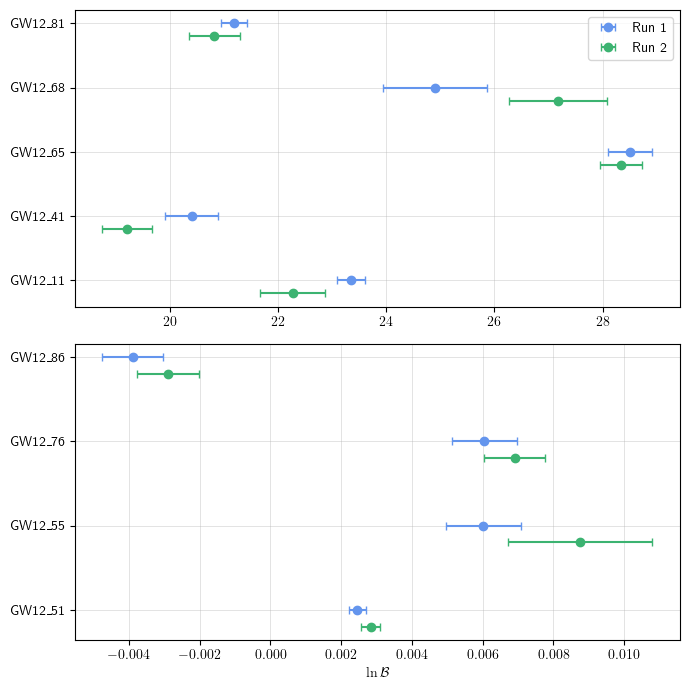

In [20]:
fig, axs = plt.subplots(2, 1, figsize=(7,7), tight_layout=True)
kwargs = dict(marker='o', capsize=3, ls='None')
idx_splits = [idx_to_load[:5], idx_to_load[5:]]
for ax, idx_split in zip(axs, idx_splits):
    eventnames = []
    for i, idx in enumerate(idx_split):
        labels = ['Run 1', 'Run 2'] if i == 0 else [None, None]
        eventname = f'GW{seed}_{idx}'
        eventnames.append(eventname)
        lnB, lnB_std = lnBayes[eventname]
        ax.errorbar(lnB, i, xerr=lnB_std, c='cornflowerblue', label=labels[0], **kwargs)
        lnB, lnB_std = lnBayes[eventname+'_rerun']
        ax.errorbar(lnB, i - 0.2, xerr=lnB_std, c='mediumseagreen', label=labels[1], **kwargs)
    ax.grid(alpha=0.5, lw=0.5)
    _ = ax.set_yticks(np.arange(len(idx_split)), labels=eventnames)
axs[1].set_xlabel(r'$\ln\mathcal B$')
axs[0].legend()